In [2]:
!pip install wfdb


     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 91.2/91.2 kB 3.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 163.8/163.8 kB 8.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 12.4/12.4 MB 79.4 MB/s eta 0:00:00
  Attempting uninstall: pandas
    Found existing installation: pandas 2.2.2
    Uninstalling pandas-2.2.2:
      Successfully uninstalled pandas-2.2.2
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
google-colab 1.0.0 requires pandas==2.2.2, but you have pandas 2.3.0 which is incompatible.
dask-cudf-cu12 25.2.2 requires pandas<2.2.4dev0,>=2.0, but you have pandas 2.3.0 which is incompatible.
cudf-cu12 25.2.1 requires pandas<2.2.4dev0,>=2.0, but you have pandas 2.3.0 which is incompatible.


**Data Loading, Exploratory Data Analysis and Preprocessing**

In [3]:
from google.colab import files
uploaded = files.upload()


Saving qt-database-1.0.0.zip to qt-database-1.0.0.zip


In [4]:
import zipfile

with zipfile.ZipFile("/content/qt-database-1.0.0.zip", 'r') as zip_ref:
    zip_ref.extractall("/content/qt-database")


**Visual Inspection of Data**

We have visualized the data in order to provide further understanding of the concept, the signals and how the data is structured.


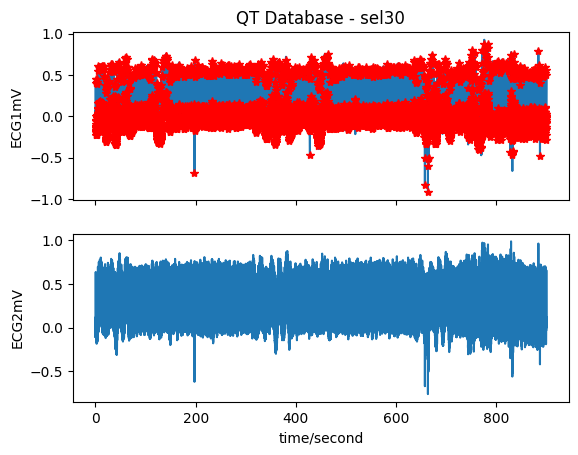

In [5]:
import wfdb

record_path = '/content/qt-database/qt-database-1.0.0/sel30'

record = wfdb.rdrecord(record_path)
annotation = wfdb.rdann(record_path, 'pu0')  # Or 'pu1', 'q1c' if available

wfdb.plot_wfdb(record=record, annotation=annotation,
               title='QT Database - sel30')


Above, one random record (sel30) is picked for visualization. .pu1 file of sel30 is visualized. .pu files contains automatically determined waveform boundary measurements for all beats (based on signal 1)

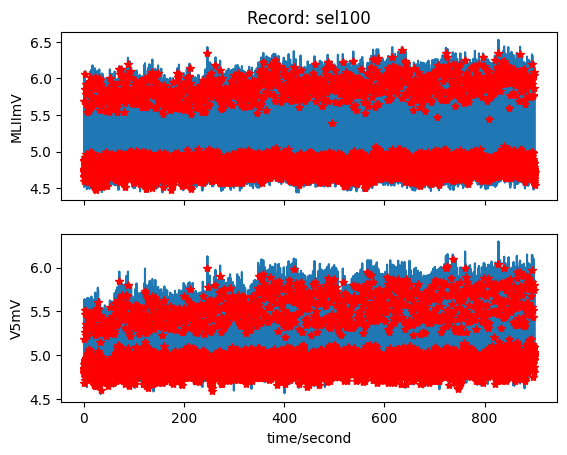

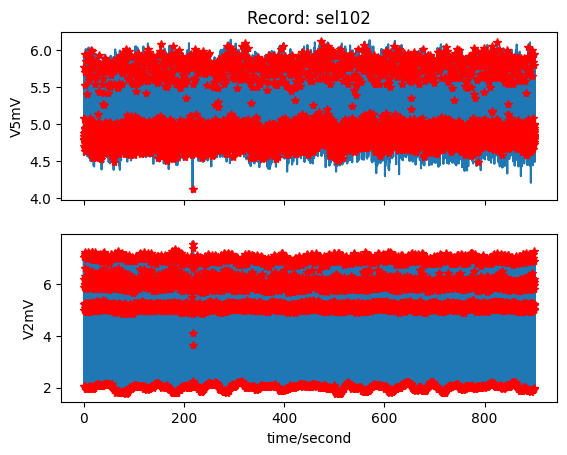

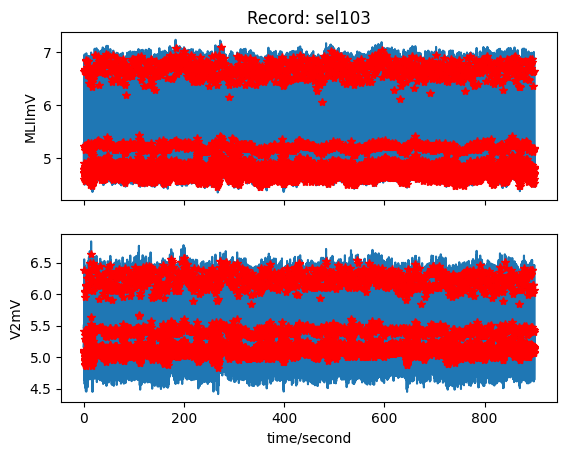

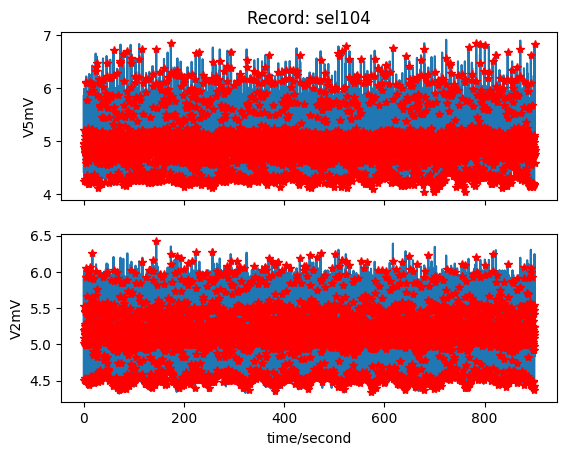

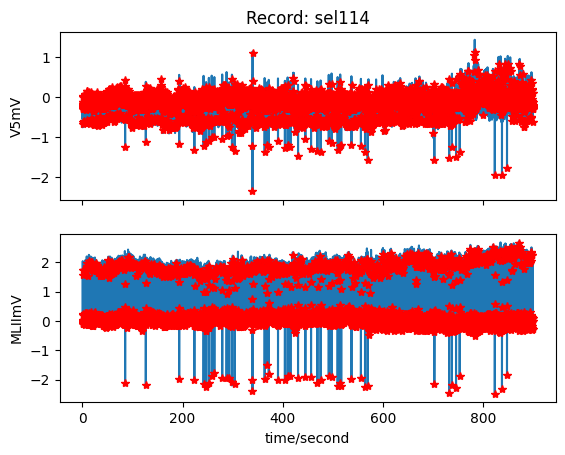

In [6]:
import os

data_dir = '/content/qt-database/qt-database-1.0.0'
record_ids = [f.split('.')[0] for f in os.listdir(data_dir) if f.endswith('.hea')] #this line creates a list of all the record names, as all records need to have a header file, we are going for the .hea
record_ids = sorted(list(set(record_ids)))  # Unique and sorted

# Function to load and plot a record
def plot_recordpu(record_id, ann_type='pu'):
    record_path = os.path.join(data_dir, record_id)
    record = wfdb.rdrecord(record_path)
    annotation = wfdb.rdann(record_path, ann_type)
    wfdb.plot_wfdb(record=record, annotation=annotation, title=f'Record: {record_id}')
# pu is chosen to be visualized bc it refers to automatically determined waveform boundary measurements for all beats (based on both signals, not just 0 or 1)

# we are loopibng through first 5 pu records as an example
for rid in record_ids[:5]:
    plot_recordpu(rid)


Below, we wanted to check the format of a header file to see what it contains. We have randomly chosen the record "sel123" for this purpose.

In [7]:
import wfdb

record_path = '/content/qt-database/qt-database-1.0.0/sel213'  # Change to your record
header = wfdb.rdheader(record_path)

# Print all header attributes
print("Record name:", header.record_name)
print("Sampling frequency (Hz):", header.fs)
print("Number of signals:", header.n_sig)
print("Signal names:", header.sig_name)
print("Signal lengths (samples):", header.sig_len)
print("Gain (ADC units per physical unit):", header.adc_gain)
print("Baseline (ADC offset):", header.baseline)
print("Units of signals:", header.units)


Record name: sel213
Sampling frequency (Hz): 250
Number of signals: 2
Signal names: ['MLII', 'V1']
Signal lengths (samples): 225000
Gain (ADC units per physical unit): [200.0, 200.0]
Baseline (ADC offset): [0, 0]
Units of signals: ['mV', 'mV']


Smapling frequency refers to the number of samples taken each second. 2 different signals exist in this record. One of them MLII and the other being V1. These refer to the different electrodes positions on the body when getting ECG. Signal length is the number of samples. Unit of signals is mV (millivolts). Gain is how we convert the signal values into actual physical unit (millivolts in our case), in our case, it converts the millovolts value into a digital number which is 200.0

What we have done before was a visual inspection of the data and provide an understanding of which file provides which information, sort of an Exploratory Data Analysis. Now that we have an understanding of the data, we will move forward with preprocessing.


In [8]:
all_files = os.listdir(data_dir)
# Check availability of q1c and q2c for each record
records_with_q1c = []
records_with_q2c = []
records_with_both = []

for rid in record_ids:
    has_q1c = f'{rid}.q1c' in all_files
    has_q2c = f'{rid}.q2c' in all_files
    if has_q1c:
        records_with_q1c.append(rid)
    if has_q2c:
        records_with_q2c.append(rid)
    if has_q1c and has_q2c:
        records_with_both.append(rid)

# Print results
print(f"✅ Records with q1c: {len(records_with_q1c)} → {records_with_q1c}")
print(f"✅ Records with q2c: {len(records_with_q2c)} → {records_with_q2c}")
print(f"✅ Records with both: {len(records_with_both)} → {records_with_both}")

✅ Records with q1c: 105 → ['sel100', 'sel102', 'sel103', 'sel104', 'sel114', 'sel116', 'sel117', 'sel123', 'sel14046', 'sel14157', 'sel14172', 'sel15814', 'sel16265', 'sel16272', 'sel16273', 'sel16420', 'sel16483', 'sel16539', 'sel16773', 'sel16786', 'sel16795', 'sel17152', 'sel17453', 'sel213', 'sel221', 'sel223', 'sel230', 'sel231', 'sel232', 'sel233', 'sel30', 'sel301', 'sel302', 'sel306', 'sel307', 'sel308', 'sel31', 'sel310', 'sel32', 'sel33', 'sel34', 'sel35', 'sel36', 'sel37', 'sel38', 'sel39', 'sel40', 'sel41', 'sel42', 'sel43', 'sel44', 'sel45', 'sel46', 'sel47', 'sel48', 'sel49', 'sel50', 'sel51', 'sel52', 'sel803', 'sel808', 'sel811', 'sel820', 'sel821', 'sel840', 'sel847', 'sel853', 'sel871', 'sel872', 'sel873', 'sel883', 'sel891', 'sele0104', 'sele0106', 'sele0107', 'sele0110', 'sele0111', 'sele0112', 'sele0114', 'sele0116', 'sele0121', 'sele0122', 'sele0124', 'sele0126', 'sele0129', 'sele0133', 'sele0136', 'sele0166', 'sele0170', 'sele0203', 'sele0210', 'sele0211', 'sele0

Here, we have determined which records have q1c and q2c files. These files contain manual, expert-made annotations of waveform boundaries by two expert annotators. We have done this step to determine which one makes sense to be used during the training phase. .q1c will be used since it applies to more records than .q2c and we dont want imbalances in the data when it comes to records. We will be extracting QRS start and T end positions from these files and use them to compute QT intervals.


**QT Extraction from q1c using beat alignment**

In [9]:
import wfdb
import os
import numpy as np

# Sampling frequency (Hz)
fs = 250

qt_results = []

for record_id in records_with_q1c:
    record_path = os.path.join(data_dir, record_id)
    try:
        annotation = wfdb.rdann(record_path, 'q1c')
        samples = annotation.sample
        symbols = annotation.symbol

        # Get sample positions for each type of symbol
        r_peaks = [s for s, sym in zip(samples, symbols) if sym == 'N']
        t_starts = [s for s, sym in zip(samples, symbols) if sym == 't']
        t_ends = [s for s, sym in zip(samples, symbols) if sym == ')']

        # Align beat by beat based on R peaks
        for r in r_peaks:
            # Find closest T start after R peak
            t_start_candidates = [t for t in t_starts if t > r]
            if not t_start_candidates:
                continue
            t_start = t_start_candidates[0]

            # Find closest T end after T start
            t_end_candidates = [te for te in t_ends if te > t_start]
            if not t_end_candidates:
                continue
            t_end = t_end_candidates[0]

            # Compute QT interval (R peak to T end)
            qt_interval_ms = ((t_end - r) / fs) * 1000

            # Only store valid QT intervals (avoid unreasonable values)
            if 200 <= qt_interval_ms <= 600:
                qt_results.append({
                    'record': record_id,
                    'qt_interval_ms': qt_interval_ms
                })

    except Exception as e:
        print(f"❗ Error in {record_id}: {e}")
        continue

# Final result
print(f"\n✅ Total QT intervals extracted: {len(qt_results)}")
for res in qt_results[:50]:
    print(res)



✅ Total QT intervals extracted: 3413
{'record': 'sel100', 'qt_interval_ms': np.float64(356.0)}
{'record': 'sel100', 'qt_interval_ms': np.float64(328.0)}
{'record': 'sel100', 'qt_interval_ms': np.float64(312.0)}
{'record': 'sel100', 'qt_interval_ms': np.float64(320.0)}
{'record': 'sel100', 'qt_interval_ms': np.float64(336.0)}
{'record': 'sel100', 'qt_interval_ms': np.float64(352.0)}
{'record': 'sel100', 'qt_interval_ms': np.float64(368.0)}
{'record': 'sel100', 'qt_interval_ms': np.float64(332.0)}
{'record': 'sel100', 'qt_interval_ms': np.float64(328.0)}
{'record': 'sel100', 'qt_interval_ms': np.float64(336.0)}
{'record': 'sel100', 'qt_interval_ms': np.float64(320.0)}
{'record': 'sel100', 'qt_interval_ms': np.float64(340.0)}
{'record': 'sel100', 'qt_interval_ms': np.float64(332.0)}
{'record': 'sel100', 'qt_interval_ms': np.float64(332.0)}
{'record': 'sel100', 'qt_interval_ms': np.float64(356.0)}
{'record': 'sel100', 'qt_interval_ms': np.float64(364.0)}
{'record': 'sel100', 'qt_interval_

Now, we are going to combine .q1c and .pu values in order to come up with a larger dataset.


In [10]:
import wfdb
import os

# Sampling frequency
fs = 250
qt_results = []

# Choose your dataset directory
data_dir = '/content/qt-database/qt-database-1.0.0/'

# Merge both record lists
all_records = sorted(list(set(records_with_q1c + record_ids)))  # Avoid duplicates

for record_id in all_records:
    record_path = os.path.join(data_dir, record_id)

    for annotator in ['q1c', 'pu']:  # Try both types, q1c has manual therefore higher quality data , pu has automatic annotations and covers more data
        try:
            ann = wfdb.rdann(record_path, annotator)
            samples = ann.sample
            symbols = ann.symbol

            # Use appropriate symbol for T-end based on annotation type
            t_end_symbol = 'T' if annotator == 'q1c' else 't'

            # Get symbol positions
            r_peaks = [s for s, sym in zip(samples, symbols) if sym == 'N']
            t_ends = [s for s, sym in zip(samples, symbols) if sym == t_end_symbol]

            for r in r_peaks:
                # Find next T-end after this R-peak
                t_candidates = [te for te in t_ends if te > r]
                if not t_candidates:
                    continue
                t_end = t_candidates[0]

                qt_ms = ((t_end - r) / fs) * 1000 #QT interval computation in milliseconds

                if 200 <= qt_ms <= 600:
                    label = 'normal' if qt_ms <= 440 else 'prolonged' # assigns a label based on clinical threshold
                    qt_results.append({
                        'record': record_id,
                        'annotator': annotator,
                        'qt_interval_ms': qt_ms,
                        'label': label
                    })
        except Exception as e:
            continue

print(f"\n✅ Total QT intervals extracted: {len(qt_results)}\n")

# 🔍 Show first 10 entries
for res in qt_results[:100]:
    print(f"Record: {res['record']} | Annotator: {res['annotator']} | QT: {res['qt_interval_ms']:.1f} ms → {res['label']}")



✅ Total QT intervals extracted: 175082

Record: sel100 | Annotator: pu | QT: 276.0 ms → normal
Record: sel100 | Annotator: pu | QT: 268.0 ms → normal
Record: sel100 | Annotator: pu | QT: 252.0 ms → normal
Record: sel100 | Annotator: pu | QT: 244.0 ms → normal
Record: sel100 | Annotator: pu | QT: 244.0 ms → normal
Record: sel100 | Annotator: pu | QT: 236.0 ms → normal
Record: sel100 | Annotator: pu | QT: 260.0 ms → normal
Record: sel100 | Annotator: pu | QT: 252.0 ms → normal
Record: sel100 | Annotator: pu | QT: 260.0 ms → normal
Record: sel100 | Annotator: pu | QT: 252.0 ms → normal
Record: sel100 | Annotator: pu | QT: 272.0 ms → normal
Record: sel100 | Annotator: pu | QT: 260.0 ms → normal
Record: sel100 | Annotator: pu | QT: 268.0 ms → normal
Record: sel100 | Annotator: pu | QT: 260.0 ms → normal
Record: sel100 | Annotator: pu | QT: 272.0 ms → normal
Record: sel100 | Annotator: pu | QT: 264.0 ms → normal
Record: sel100 | Annotator: pu | QT: 256.0 ms → normal
Record: sel100 | Annotat

The code snippet below is used to demonstrate how many of these records belong to prolonged records. And we have seen that prolonged records make up only 2540 of the records while the whole dataset is 175082.

In [11]:
# Filter prolonged QT intervals
prolonged_qts = [entry for entry in qt_results if entry['label'] == 'prolonged']

# Print results
print(f"🔎 Total prolonged QT intervals: {len(prolonged_qts)}\n")
for entry in prolonged_qts[:10]:  # print first 10 for preview
    print(f"Record: {entry['record']} | Annotator: {entry['annotator']} | QT: {entry['qt_interval_ms']:.1f} ms → {entry['label']}")


🔎 Total prolonged QT intervals: 2540

Record: sel114 | Annotator: pu | QT: 496.0 ms → prolonged
Record: sel114 | Annotator: pu | QT: 452.0 ms → prolonged
Record: sel114 | Annotator: pu | QT: 544.0 ms → prolonged
Record: sel123 | Annotator: pu | QT: 500.0 ms → prolonged
Record: sel123 | Annotator: pu | QT: 496.0 ms → prolonged
Record: sel15814 | Annotator: pu | QT: 516.0 ms → prolonged
Record: sel15814 | Annotator: pu | QT: 508.0 ms → prolonged
Record: sel213 | Annotator: pu | QT: 564.0 ms → prolonged
Record: sel213 | Annotator: pu | QT: 564.0 ms → prolonged
Record: sel213 | Annotator: pu | QT: 576.0 ms → prolonged


In [12]:
import random

# Separate again
normal_qts = [e for e in qt_results if e['label'] == 'normal']
prolonged_qts = [e for e in qt_results if e['label'] == 'prolonged']

#target size per class
target_size = 30000

# Undersample normal
undersampled_normals = random.sample(normal_qts, target_size)

# Oversample prolonged (with replacement)
oversampled_prolonged = random.choices(prolonged_qts, k=target_size)

# Combine and shuffle
balanced_qt_results = undersampled_normals + oversampled_prolonged
random.shuffle(balanced_qt_results)

# Summary
print(f"✅ Mixed resampling complete.")
print(f"🟢 Normal: {len(undersampled_normals)}, 🔴 Prolonged: {len(oversampled_prolonged)}")
print(f"🔢 Total: {len(balanced_qt_results)}")

✅ Mixed resampling complete.
🟢 Normal: 30000, 🔴 Prolonged: 30000
🔢 Total: 60000


We have decided to go for an unproach of undersampling the "normal" classified values since it was relatively too much, compared to the "prolonged" values. While doing that, we have also oversampled the "prolonged" values and adopted a hybrid resampling approach. In the end, we had 30000 "normal" values and 30000 "prolonged" values. This way we have prevented imbalances in the dataset and overfitting. 30000 samples per class is chosen considering the lower limit that would risk underfitting which would be around 10k-20k and the upper limit which would risk overfitting and slower training time in colab which is around +50k.


In [13]:
import numpy as np
from tqdm import tqdm

# Parameters
fs = 250
window_size = 500  # 2 seconds
half_window = window_size // 2

X = []
y = []

for entry in tqdm(balanced_qt_results, desc="Extracting ECG windows"):
    record_id = entry['record']
    annotator = entry['annotator']
    label = 1 if entry['label'] == 'prolonged' else 0

    try:
        # Load signal
        record_path = os.path.join(data_dir, record_id)
        record = wfdb.rdrecord(record_path)
        signal = record.p_signal[:, 0]  # channel 0, which is MLII, more informative for QRS or QT analysis (medically) than channel 1 which is V1

        # Load annotation
        ann = wfdb.rdann(record_path, annotator)
        samples = ann.sample
        symbols = ann.symbol

        # Find matching R-peak sample for this beat
        r_peaks = [s for s, sym in zip(samples, symbols) if sym == 'N'] #N annotates the R-peaks
        # We assume the matching R peak is the first one before the QT interval's end
        matched_r = None
        for r in r_peaks:
            if (r + half_window < len(signal)) and (r - half_window >= 0): #make sure the first R-peak has enough room before and after it to extract a 500-sample window
                matched_r = r
                break

        if matched_r is None:
            continue  # skip if window would go out of bounds


        window = signal[matched_r - half_window : matched_r + half_window] #the 2-second window centered on the R-peak

        # Normalize (z-score)
        window = (window - np.mean(window)) / (np.std(window) + 1e-6)

        # Save
        X.append(window)
        y.append(label) # 1 = prolonged, 0 = normal

    except Exception as e:
        print(f"⚠️ Skipping {record_id}: {e}")
        continue

# Convert to numpy arrays
X = np.array(X)
y = np.array(y)

print(f"\n✅ Signal extraction complete: {X.shape[0]} samples, each {X.shape[1]} long")


Extracting ECG windows: 100%|██████████| 60000/60000 [1:59:47<00:00,  8.35it/s]


✅ Signal extraction complete: 60000 samples, each 500 long


This step above transformed our labeled balanced_qt_results into model-ready signal data (x) and target labels (y). It is like the step between preprocessing and deep learning.

In [14]:
import numpy as np

# Save arrays
np.save('/content/X.npy', X)
np.save('/content/y.npy', y)

#this step was added in order to ease our job with google colab resetting itself, not directly related with the project


**Visualization of QT extraction**

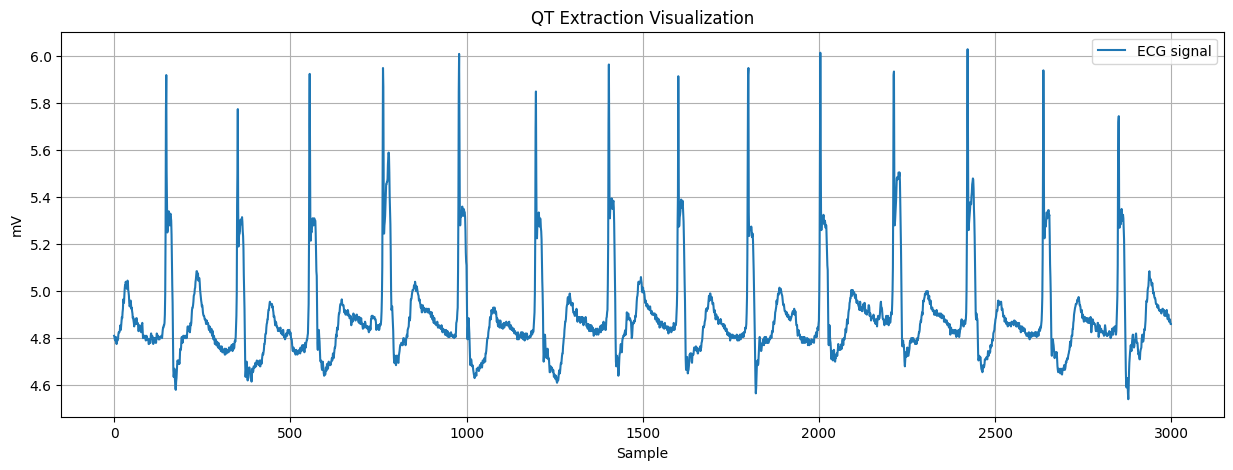

In [15]:
import wfdb
import matplotlib.pyplot as plt

# Select a record to visualize
record_path = '/content/qt-database/qt-database-1.0.0/sel102'
fs = 250

record = wfdb.rdrecord(record_path)
annotation = wfdb.rdann(record_path, 'q1c')

samples = annotation.sample
symbols = annotation.symbol

r_peaks = [s for s, sym in zip(samples, symbols) if sym == 'N']
t_starts = [s for s, sym in zip(samples, symbols) if sym == 't']
t_ends = [s for s, sym in zip(samples, symbols) if sym == ')']

start = 0
end = 3000

plt.figure(figsize=(15, 5))
plt.plot(range(start, end), record.p_signal[start:end, 0], label='ECG signal')
plt.title('QT Extraction Visualization')
plt.xlabel('Sample')
plt.ylabel('mV')
plt.grid()

for r in r_peaks:
    if start <= r <= end:
        plt.plot(r, record.p_signal[r, 0], 'ro', label='R peak' if 'R peak' not in plt.gca().get_legend_handles_labels()[1] else "")

        t_start_candidates = [t for t in t_starts if t > r]
        if not t_start_candidates:
            continue
        t_start = t_start_candidates[0]

        t_end_candidates = [te for te in t_ends if te > t_start]
        if not t_end_candidates:
            continue
        t_end = t_end_candidates[0]

        plt.plot(t_start, record.p_signal[t_start, 0], 'go', label='T start' if 'T start' not in plt.gca().get_legend_handles_labels()[1] else "")
        plt.plot(t_end, record.p_signal[t_end, 0], 'mo', label='T end' if 'T end' not in plt.gca().get_legend_handles_labels()[1] else "")

plt.legend()
plt.show()


In this step, one ECG record (sel102) was visualized to display the raw ECG signal used for QT interval extraction.

**Model Architecture & Training**

In [16]:
import numpy as np
from sklearn.model_selection import train_test_split

# Load preprocessed data
X = np.load('/content/X.npy')
y = np.load('/content/y.npy')

# Split into train and test sets, use of stratification to preserve class balance
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

# Reshape for CNN input: (samples, time_steps, channels) # since 1D CNN's expect 3D input, we add another dimension
X_train = X_train[..., np.newaxis]
X_test = X_test[..., np.newaxis]

#the new dimension is "channels", how many streams there are and since we will be using MLII, its 1
print("Train shape:", X_train.shape)
print("Test shape:", X_test.shape)



Train shape: (48000, 500, 1)
Test shape: (12000, 500, 1)


The dimensions of the train and test data are now 3, which are ("samples", "time_steps", "channels"). "Samples" being how many ECG segments we are training on, "time_steps" is how long each ECG segment is (500 samples = 2 seconds), "channel" is how many signal streams there are for MLII (its 1 for MLII).

/usr/local/lib/python3.11/dist-packages/keras/src/layers/convolutional/base_conv.py:107: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Epoch 1/50
1200/1200 ━━━━━━━━━━━━━━━━━━━━ 56s 44ms/step - accuracy: 0.9418 - loss: 0.2181 - val_accuracy: 0.9586 - val_loss: 0.1242
Epoch 2/50
1200/1200 ━━━━━━━━━━━━━━━━━━━━ 49s 41ms/step - accuracy: 0.9564 - loss: 0.1498 - val_accuracy: 0.9598 - val_loss: 0.1203
Epoch 3/50
1200/1200 ━━━━━━━━━━━━━━━━━━━━ 82s 41ms/step - accuracy: 0.9572 - loss: 0.1436 - val_accuracy: 0.9609 - val_loss: 0.1244
Epoch 4/50
1200/1200 ━━━━━━━━━━━━━━━━━━━━ 49s 41ms/step - accuracy: 0.9556 - loss: 0.1425 - val_accuracy: 0.9586 - val_loss: 0.1195
Epoch 5/50
1200/1200 ━━━━━━━━━━━━━━━━━━━━ 83s 42ms/step - accuracy: 0.9593 - loss: 0.1303 - val_accuracy: 0.9566 - val_loss: 0.1235
Epoch 6/50
1200/1200 ━━━━━━━━━━━━━━━━━━━━ 81s 41ms/step - accuracy: 0.9573 - loss: 0.1359 - val_accuracy: 0.9600 - val_loss: 0.1198
Epoch 7/50
1200/1200 ━━━━━━━━━━━━━━━━━━━━ 82s 41ms/step - accuracy: 0.9598 - loss: 0.1328 - val_accuracy: 0.9600 - val_loss: 0.1171
Epoch 8/50
1200/1200 ━━━━━━━━━━━━━━━━━━━━ 81s 40ms/step - accuracy: 0.9586 -

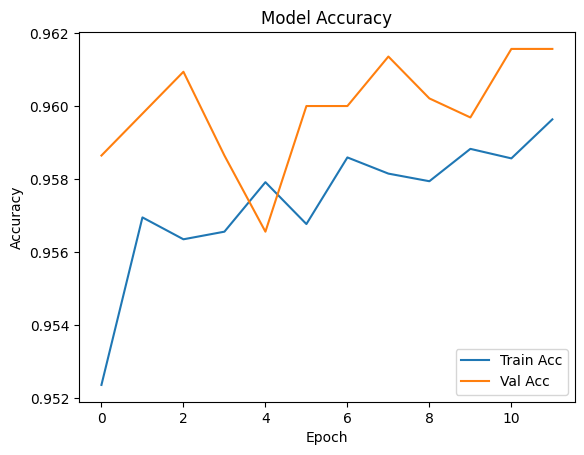

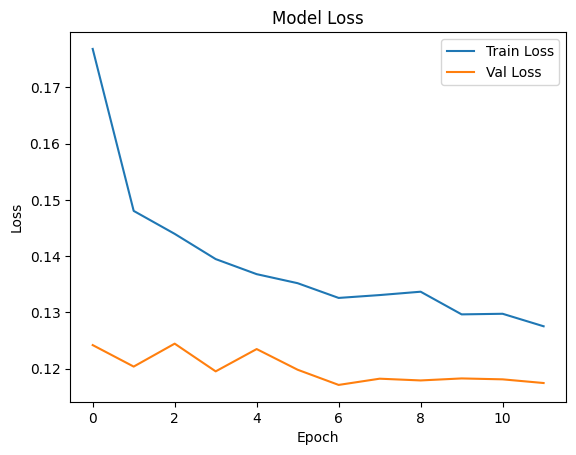

In [17]:
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Conv1D, MaxPooling1D, Flatten, Dense, Dropout, BatchNormalization
from tensorflow.keras.callbacks import EarlyStopping

# Define 1D CNN model
model = Sequential()

# First convolutional block
model.add(Conv1D(filters=32, kernel_size=5, activation='relu', input_shape=(500, 1)))
model.add(BatchNormalization())
model.add(MaxPooling1D(pool_size=2))

# Second convolutional block
model.add(Conv1D(filters=64, kernel_size=3, activation='relu'))
model.add(BatchNormalization())
model.add(MaxPooling1D(pool_size=2))

# Fully connected layers
model.add(Flatten())
model.add(Dense(64, activation='relu'))
model.add(Dropout(0.5))
model.add(Dense(1, activation='sigmoid'))  # binary classification

# Compile the model
model.compile(optimizer='adam', loss='binary_crossentropy', metrics=['accuracy'])

# early stopping is implemented to avoid overfitting
early_stop = EarlyStopping(monitor='val_loss', patience=5, restore_best_weights=True)


# we are training the model with 20% validation split
history = model.fit(
    X_train, y_train,
    epochs=50,
    batch_size=32,
    validation_split=0.2,
    callbacks=[early_stop]
)

model.save('/content/model.h5')

# Visualize training history
import matplotlib.pyplot as plt

# Plot accuracy
plt.plot(history.history['accuracy'], label='Train Acc')
plt.plot(history.history['val_accuracy'], label='Val Acc')
plt.title('Model Accuracy')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend()
plt.show()

# Plot loss
plt.plot(history.history['loss'], label='Train Loss')
plt.plot(history.history['val_loss'], label='Val Loss')
plt.title('Model Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()
plt.show()



From the visualization of the Model Accuracy, it can be said that both curves stabilize around 0.96 point and there is no major divergence from each other. This graph indicates that the model is learning well on the training data and is also generalizing well on unseen data and there is no sign of overfitting. On the Model Loss graph, loss decreases steadily for both train and validation sets and there are no major gaps between them, the validation curve is even lower in some parts which is a good sign.

**Evaluation**

In [18]:
# Evaluate model on test set
test_loss, test_accuracy = model.evaluate(X_test, y_test)
print(f"Test Accuracy: {test_accuracy*100:.2f}%")
print(f"Test Loss: {test_loss:.4f}")


375/375 ━━━━━━━━━━━━━━━━━━━━ 3s 9ms/step - accuracy: 0.9588 - loss: 0.1229
Test Accuracy: 96.13%
Test Loss: 0.1185


The model generalizes well on unseen data and was not overfitting. Loss is low and along with the high accuracy, it inciates a good performing model.

In [19]:
from sklearn.metrics import confusion_matrix, classification_report

# Get predictions
y_pred_prob = model.predict(X_test)
y_pred = (y_pred_prob > 0.5).astype("int32")

# Confusion Matrix
cm = confusion_matrix(y_test, y_pred)
print("Confusion Matrix:\n", cm)

# Classification Report
print("\nClassification Report:\n", classification_report(y_test, y_pred))


375/375 ━━━━━━━━━━━━━━━━━━━━ 4s 10ms/step
Confusion Matrix:
 [[5767  233]
 [ 232 5768]]

Classification Report:
               precision    recall  f1-score   support

           0       0.96      0.96      0.96      6000
           1       0.96      0.96      0.96      6000

    accuracy                           0.96     12000
   macro avg       0.96      0.96      0.96     12000
weighted avg       0.96      0.96      0.96     12000



*   TP: 5767
*   FP: 233
*   FN: 232
*   TN: 5768

*   Precision -> how many of the predicted class were predicted correctly
*   Recall -> how many of the actual class were captured
*   F1- score -> harmonic mean of precision and recall

All classification metrics are balanced and strong (0.96) for both classes and this shows that the model is accurate and fair with no major imbalance.






In [20]:
from sklearn.metrics import roc_auc_score

roc_auc = roc_auc_score(y_test, y_pred_prob)
print(f"ROC-AUC: {roc_auc:.4f}")


ROC-AUC: 0.9903


ROC-AUC stands for Receiver Operating Characteristics - Area Under the Curve, it measures the model's ability to distinguish between classes and it evaluates the model across all thresholds.
 1.0 would refer to perfect classification and our value is 0.9903, which is excellent.


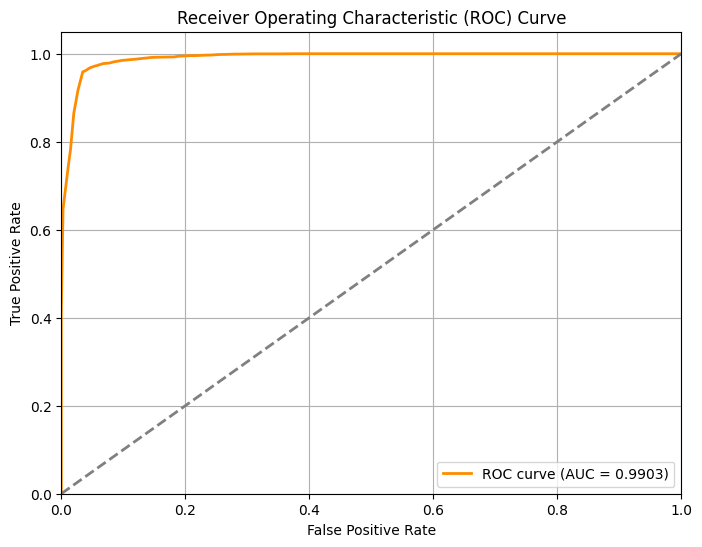

In [21]:
from sklearn.metrics import roc_curve, auc
import matplotlib.pyplot as plt

# Compute ROC curve and AUC
fpr, tpr, thresholds = roc_curve(y_test, y_pred_prob)
roc_auc = auc(fpr, tpr)

# Plot
plt.figure(figsize=(8, 6))
plt.plot(fpr, tpr, color='darkorange', lw=2, label=f'ROC curve (AUC = {roc_auc:.4f})')
plt.plot([0, 1], [0, 1], color='gray', lw=2, linestyle='--')  # Diagonal line
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('Receiver Operating Characteristic (ROC) Curve')
plt.legend(loc='lower right')
plt.grid(True)
plt.show()
